<a href="https://colab.research.google.com/github/midhun7523/DNA-Kmer-Classifier/blob/main/notebooks/01_dataset_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("DNA K-mer Classifier")
print("Starting dataset exploration...")

DNA K-mer Classifier
Starting dataset exploration...


In [2]:
import pandas as pd

In [4]:
!git clone https://github.com/midhun7523/DNA-Kmer-Classifier.git

Cloning into 'DNA-Kmer-Classifier'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 34 (delta 10), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 11.99 KiB | 1.50 MiB/s, done.
Resolving deltas: 100% (10/10), done.


In [5]:
!ls DNA-Kmer-Classifier/data

promoters.data


In [7]:
file_path = "DNA-Kmer-Classifier/data/promoters.data"

with open(file_path, "r") as file:
    lines = file.readlines()

print("Number of lines:", len(lines))

Number of lines: 106


In [9]:
for line in lines[:15]:
    print(line)

+,S10,		tactagcaatacgcttgcgttcggtggttaagtatgtataatgcgcgggcttgtcgt

+,AMPC,		tgctatcctgacagttgtcacgctgattggtgtcgttacaatctaacgcatcgccaa

+,AROH,		gtactagagaactagtgcattagcttatttttttgttatcatgctaaccacccggcg

+,DEOP2,	aattgtgatgtgtatcgaagtgtgttgcggagtagatgttagaatactaacaaactc

+,LEU1_TRNA,	tcgataattaactattgacgaaaagctgaaaaccactagaatgcgcctccgtggtag

+,MALEFG,	aggggcaaggaggatggaaagaggttgccgtataaagaaactagagtccgtttaggt

+,MALK,		cagggggtggaggatttaagccatctcctgatgacgcatagtcagcccatcatgaat

+,RECA,		tttctacaaaacacttgatactgtatgagcatacagtataattgcttcaacagaaca

+,RPOB,		cgacttaatatactgcgacaggacgtccgttctgtgtaaatcgcaatgaaatggttt

+,RRNAB_P1,	ttttaaatttcctcttgtcaggccggaataactccctataatgcgccaccactgaca

+,RRNAB_P2,	gcaaaaataaatgcttgactctgtagcgggaaggcgtattatgcacaccccgcgccg

+,RRNDEX_P2,	cctgaaattcagggttgactctgaaagaggaaagcgtaatatacgccacctcgcgac

+,RRND_P1,	gatcaaaaaaatacttgtgcaaaaaattgggatccctataatgcgcctccgttgaga

+,RRNE_P1,	ctgcaatttttctattgcggcctgcggagaactccctataatgcgcctccatcgaca

+,RRNG_P1,	tttatatttttcgcttgtc

In [12]:
df = pd.read_csv(
    file_path,
    sep=r"\s+",
    header=None,
    engine="python")

df.head()

'+,S10,\t\ttactagcaatacgcttgcgttcggtggttaagtatgtataatgcgcgggcttgtcgt\n'
'+,AMPC,\t\ttgctatcctgacagttgtcacgctgattggtgtcgttacaatctaacgcatcgccaa\n'
'+,AROH,\t\tgtactagagaactagtgcattagcttatttttttgttatcatgctaaccacccggcg\n'
'+,DEOP2,\taattgtgatgtgtatcgaagtgtgttgcggagtagatgttagaatactaacaaactc\n'
'+,LEU1_TRNA,\ttcgataattaactattgacgaaaagctgaaaaccactagaatgcgcctccgtggtag\n'


In [14]:
import pandas as pd

file_path = "DNA-Kmer-Classifier/data/promoters.data"

df = pd.read_csv(
    file_path,
    header=None,
    names=["Label", "ID", "Sequence"],
    sep=",",
    engine="python"
)

df.head()

,Label,ID,Sequence
0,+,S10,\t\ttactagcaatacgcttgcgttcggtggttaagtatgtataat...
1,+,AMPC,\t\ttgctatcctgacagttgtcacgctgattggtgtcgttacaat...
2,+,AROH,\t\tgtactagagaactagtgcattagcttatttttttgttatcat...
3,+,DEOP2,\taattgtgatgtgtatcgaagtgtgttgcggagtagatgttagaa...
4,+,LEU1_TRNA,\ttcgataattaactattgacgaaaagctgaaaaccactagaatgc...


In [15]:
print(df.shape)
print(df.head())


(106, 3)
  Label         ID                                           Sequence
0     +        S10  \t\ttactagcaatacgcttgcgttcggtggttaagtatgtataat...
1     +       AMPC  \t\ttgctatcctgacagttgtcacgctgattggtgtcgttacaat...
2     +       AROH  \t\tgtactagagaactagtgcattagcttatttttttgttatcat...
3     +      DEOP2  \taattgtgatgtgtatcgaagtgtgttgcggagtagatgttagaa...
4     +  LEU1_TRNA  \ttcgataattaactattgacgaaaagctgaaaaccactagaatgc...


In [16]:
df["Sequence"] = df["Sequence"].str.strip().str.upper()

In [17]:
print(df.head())

  Label         ID                                           Sequence
0     +        S10  TACTAGCAATACGCTTGCGTTCGGTGGTTAAGTATGTATAATGCGC...
1     +       AMPC  TGCTATCCTGACAGTTGTCACGCTGATTGGTGTCGTTACAATCTAA...
2     +       AROH  GTACTAGAGAACTAGTGCATTAGCTTATTTTTTTGTTATCATGCTA...
3     +      DEOP2  AATTGTGATGTGTATCGAAGTGTGTTGCGGAGTAGATGTTAGAATA...
4     +  LEU1_TRNA  TCGATAATTAACTATTGACGAAAAGCTGAAAACCACTAGAATGCGC...


In [18]:
df["Class"] = df["Label"].map({
    "+": "Promoter",
    "-": "Non-Promoter"
})

df.head()

,Label,ID,Sequence,Class
0,+,S10,TACTAGCAATACGCTTGCGTTCGGTGGTTAAGTATGTATAATGCGC...,Promoter
1,+,AMPC,TGCTATCCTGACAGTTGTCACGCTGATTGGTGTCGTTACAATCTAA...,Promoter
2,+,AROH,GTACTAGAGAACTAGTGCATTAGCTTATTTTTTTGTTATCATGCTA...,Promoter
3,+,DEOP2,AATTGTGATGTGTATCGAAGTGTGTTGCGGAGTAGATGTTAGAATA...,Promoter
4,+,LEU1_TRNA,TCGATAATTAACTATTGACGAAAAGCTGAAAACCACTAGAATGCGC...,Promoter


In [21]:
print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df["Class"].value_counts())
print("\nSequence lengths:")
print(df["Sequence"].str.len().value_counts())

Dataset shape: (106, 4)

Class distribution:
Class
Promoter        53
Non-Promoter    53
Name: count, dtype: int64

Sequence lengths:
Sequence
57    106
Name: count, dtype: int64


In [22]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Label       0
ID          0
Sequence    0
Class       0
dtype: int64


In [23]:
clean_file_path = "DNA-Kmer-Classifier/data/promoter_sequences_clean.csv"

df.to_csv(clean_file_path, index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [24]:
print(df.shape)
print(df["Class"].value_counts())
print(df["Sequence"].str.len().value_counts())

(106, 4)
Class
Promoter        53
Non-Promoter    53
Name: count, dtype: int64
Sequence
57    106
Name: count, dtype: int64


In [25]:
def get_kmers(sequence, k=3):
    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]

example_sequence = "ATGCGTA"

print(get_kmers(example_sequence, 3))

#Why len(sequence) - k + 1?
For a sequence of length 7 and k = 3:
7 - 3 + 1 = 5
So we get 5 K-mers.

['ATG', 'TGC', 'GCG', 'CGT', 'GTA']


In [26]:
def get_kmers(sequence, k=3):
    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]


df["Kmers"] = df["Sequence"].apply(get_kmers)

df[["ID", "Sequence", "Kmers"]].head()

,ID,Sequence,Kmers
0,S10,TACTAGCAATACGCTTGCGTTCGGTGGTTAAGTATGTATAATGCGC...,"[TAC, ACT, CTA, TAG, AGC, GCA, CAA, AAT, ATA, ..."
1,AMPC,TGCTATCCTGACAGTTGTCACGCTGATTGGTGTCGTTACAATCTAA...,"[TGC, GCT, CTA, TAT, ATC, TCC, CCT, CTG, TGA, ..."
2,AROH,GTACTAGAGAACTAGTGCATTAGCTTATTTTTTTGTTATCATGCTA...,"[GTA, TAC, ACT, CTA, TAG, AGA, GAG, AGA, GAA, ..."
3,DEOP2,AATTGTGATGTGTATCGAAGTGTGTTGCGGAGTAGATGTTAGAATA...,"[AAT, ATT, TTG, TGT, GTG, TGA, GAT, ATG, TGT, ..."
4,LEU1_TRNA,TCGATAATTAACTATTGACGAAAAGCTGAAAACCACTAGAATGCGC...,"[TCG, CGA, GAT, ATA, TAA, AAT, ATT, TTA, TAA, ..."


In [27]:
print("ID:", df.iloc[0]["ID"])
print("Class:", df.iloc[0]["Class"])
print("Number of K-mers:", len(df.iloc[0]["Kmers"]))
print("First 10 K-mers:", df.iloc[0]["Kmers"][:10])

ID: S10
Class: Promoter
Number of K-mers: 55
First 10 K-mers: ['TAC', 'ACT', 'CTA', 'TAG', 'AGC', 'GCA', 'CAA', 'AAT', 'ATA', 'TAC']


In [28]:
from collections import Counter

def kmer_frequency(sequence, k=3):
    kmers = get_kmers(sequence, k)
    return Counter(kmers)

df["Kmer_Counts"] = df["Sequence"].apply(kmer_frequency)

df[["ID", "Class", "Kmer_Counts"]].head()

,ID,Class,Kmer_Counts
0,S10,Promoter,"{'TAC': 2, 'ACT': 1, 'CTA': 1, 'TAG': 1, 'AGC'..."
1,AMPC,Promoter,"{'TGC': 1, 'GCT': 2, 'CTA': 2, 'TAT': 1, 'ATC'..."
2,AROH,Promoter,"{'GTA': 1, 'TAC': 1, 'ACT': 2, 'CTA': 3, 'TAG'..."
3,DEOP2,Promoter,"{'AAT': 2, 'ATT': 1, 'TTG': 2, 'TGT': 6, 'GTG'..."
4,LEU1_TRNA,Promoter,"{'TCG': 1, 'CGA': 2, 'GAT': 1, 'ATA': 1, 'TAA'..."


In [30]:
print(df.iloc[0]["Kmer_Counts"])

Counter({'GCG': 3, 'TAC': 2, 'AAT': 2, 'ATA': 2, 'CGC': 2, 'GCT': 2, 'CTT': 2, 'TTG': 2, 'TGC': 2, 'CGT': 2, 'GTT': 2, 'TCG': 2, 'CGG': 2, 'GGT': 2, 'TAA': 2, 'GTA': 2, 'TAT': 2, 'ATG': 2, 'TGT': 2, 'ACT': 1, 'CTA': 1, 'TAG': 1, 'AGC': 1, 'GCA': 1, 'CAA': 1, 'ACG': 1, 'TTC': 1, 'GTG': 1, 'TGG': 1, 'TTA': 1, 'AAG': 1, 'AGT': 1, 'GGG': 1, 'GGC': 1, 'GTC': 1})


### STEP 6 — Count K-mers

Now create a function that counts how often each 3-mer occurs. We've already defined `get_kmers` earlier. Let's apply the `kmer_frequency` function to the complete dataset and display the head of the DataFrame to see the new `Kmer_Counts` column.

In [31]:
from collections import Counter

def kmer_frequency(sequence, k=3):
    kmers = get_kmers(sequence, k)
    return Counter(kmers)

df["Kmer_Counts"] = df["Sequence"].apply(kmer_frequency)

df[["ID", "Class", "Kmer_Counts"]].head()

,ID,Class,Kmer_Counts
0,S10,Promoter,"{'TAC': 2, 'ACT': 1, 'CTA': 1, 'TAG': 1, 'AGC'..."
1,AMPC,Promoter,"{'TGC': 1, 'GCT': 2, 'CTA': 2, 'TAT': 1, 'ATC'..."
2,AROH,Promoter,"{'GTA': 1, 'TAC': 1, 'ACT': 2, 'CTA': 3, 'TAG'..."
3,DEOP2,Promoter,"{'AAT': 2, 'ATT': 1, 'TTG': 2, 'TGT': 6, 'GTG'..."
4,LEU1_TRNA,Promoter,"{'TCG': 1, 'CGA': 2, 'GAT': 1, 'ATA': 1, 'TAA'..."


### STEP 7 — Convert K-mer counts into ML features

Machine-learning models cannot directly understand `Counter({'TAC': 2, 'ACT': 1, ...})`. We need to convert these into a numerical matrix. We'll use `DictVectorizer` from `sklearn.feature_extraction` to convert the `Kmer_Counts` into a feature matrix `X`, and extract the `Class` labels into `y`.

In [32]:
from sklearn.feature_extraction import DictVectorizer

vectorizer = DictVectorizer()

X = vectorizer.fit_transform(df["Kmer_Counts"]).toarray()

y = df["Class"]

print("Feature matrix shape:", X.shape)
print("Number of K-mer features:", len(vectorizer.get_feature_names_out()))

Feature matrix shape: (106, 64)
Number of K-mer features: 64


The feature matrix shape should be (106, 64) because there are 106 sequences and 64 possible 3-mer combinations (4 bases ^ 3 length = 64).

### STEP 8 — See the feature names

Let's inspect the names of the features (K-mers) that the vectorizer has created.

In [33]:
feature_names = vectorizer.get_feature_names_out()

print(feature_names)

['AAA' 'AAC' 'AAG' 'AAT' 'ACA' 'ACC' 'ACG' 'ACT' 'AGA' 'AGC' 'AGG' 'AGT'
 'ATA' 'ATC' 'ATG' 'ATT' 'CAA' 'CAC' 'CAG' 'CAT' 'CCA' 'CCC' 'CCG' 'CCT'
 'CGA' 'CGC' 'CGG' 'CGT' 'CTA' 'CTC' 'CTG' 'CTT' 'GAA' 'GAC' 'GAG' 'GAT'
 'GCA' 'GCC' 'GCG' 'GCT' 'GGA' 'GGC' 'GGG' 'GGT' 'GTA' 'GTC' 'GTG' 'GTT'
 'TAA' 'TAC' 'TAG' 'TAT' 'TCA' 'TCC' 'TCG' 'TCT' 'TGA' 'TGC' 'TGG' 'TGT'
 'TTA' 'TTC' 'TTG' 'TTT']


### STEP 9 — Create a dataframe of features

For better readability and understanding, we'll convert our feature matrix `X` into a Pandas DataFrame, using the `feature_names` as column headers.

In [34]:
X_df = pd.DataFrame(
    X,
    columns=feature_names
)

X_df.head()

,AAA,AAC,AAG,AAT,ACA,ACC,ACG,ACT,AGA,AGC,...,TCG,TCT,TGA,TGC,TGG,TGT,TTA,TTC,TTG,TTT
0,0.0,0.0,1.0,2.0,0.0,0.0,1.0,1.0,0.0,1.0,...,2.0,0.0,0.0,2.0,1.0,2.0,1.0,1.0,2.0,0.0
1,0.0,1.0,0.0,1.0,2.0,0.0,2.0,0.0,0.0,0.0,...,2.0,1.0,2.0,1.0,1.0,2.0,1.0,0.0,2.0,0.0
2,0.0,2.0,0.0,0.0,0.0,2.0,0.0,2.0,2.0,1.0,...,0.0,0.0,0.0,2.0,0.0,1.0,3.0,0.0,1.0,5.0
3,1.0,2.0,1.0,2.0,1.0,0.0,0.0,2.0,2.0,0.0,...,1.0,0.0,1.0,1.0,0.0,6.0,1.0,0.0,2.0,0.0
4,4.0,2.0,1.0,2.0,0.0,1.0,1.0,2.0,1.0,1.0,...,1.0,0.0,2.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0


### STEP 10 — Convert labels into numbers

Machine learning models typically work with numerical labels. We will convert our categorical labels ('Promoter', 'Non-Promoter') into numerical format (1, 0 respectively).

In [35]:
y_numeric = y.map({
    "Non-Promoter": 0,
    "Promoter": 1
})

print(y_numeric.value_counts())

Class
1    53
0    53
Name: count, dtype: int64


### STEP 11 — Split the dataset

Now, we'll split our data into training and testing sets. The model will learn from the training data and be evaluated on the unseen testing data. We'll use an 80/20 split with stratification to maintain the class distribution.

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_numeric,
    test_size=0.20,
    random_state=42,
    stratify=y_numeric
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 84
Testing samples: 22


### STEP 12 — Train Logistic Regression

We'll start by training a Logistic Regression model, a common choice for binary classification. We'll set `max_iter` to prevent convergence warnings and `random_state` for reproducibility.

In [37]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)

### STEP 13 — Evaluate Logistic Regression

Now, let's evaluate the performance of our Logistic Regression model using several common metrics: Accuracy, Precision, Recall, and F1 Score.

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Logistic Regression Results")

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("Precision:",
      precision_score(y_test, y_pred_lr))

print("Recall:",
      recall_score(y_test, y_pred_lr))

print("F1 Score:",
      f1_score(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.7727272727272727
Precision: 0.875
Recall: 0.6363636363636364
F1 Score: 0.7368421052631579


### STEP 14 — Classification report

The classification report provides a more detailed breakdown of the precision, recall, and F1-score for each class.

In [39]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Non-Promoter", "Promoter"]
    )
)

              precision    recall  f1-score   support

Non-Promoter       0.71      0.91      0.80        11
    Promoter       0.88      0.64      0.74        11

    accuracy                           0.77        22
   macro avg       0.79      0.77      0.77        22
weighted avg       0.79      0.77      0.77        22



### STEP 15 — Confusion Matrix

A confusion matrix visually summarizes the performance of a classification algorithm, showing true positives, true negatives, false positives, and false negatives.

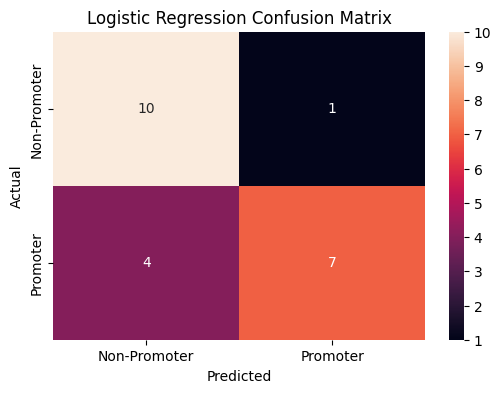

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Non-Promoter", "Promoter"],
    yticklabels=["Non-Promoter", "Promoter"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

### STEP 16 — Train a Random Forest

Now, let's train a second machine learning model, a Random Forest Classifier, and compare its performance to Logistic Regression. Random Forests are ensemble methods that often provide good performance.

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

### STEP 17 — Evaluate Random Forest

We'll evaluate the Random Forest model using the same metrics as Logistic Regression and generate its classification report.

In [42]:
print("Random Forest Results")

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Non-Promoter", "Promoter"]
    )
)

Random Forest Results
Accuracy: 0.8636363636363636
Precision: 0.9
Recall: 0.8181818181818182
F1 Score: 0.8571428571428571
              precision    recall  f1-score   support

Non-Promoter       0.83      0.91      0.87        11
    Promoter       0.90      0.82      0.86        11

    accuracy                           0.86        22
   macro avg       0.87      0.86      0.86        22
weighted avg       0.87      0.86      0.86        22



### STEP 18 — Random Forest confusion matrix

And here's the confusion matrix for the Random Forest Classifier.

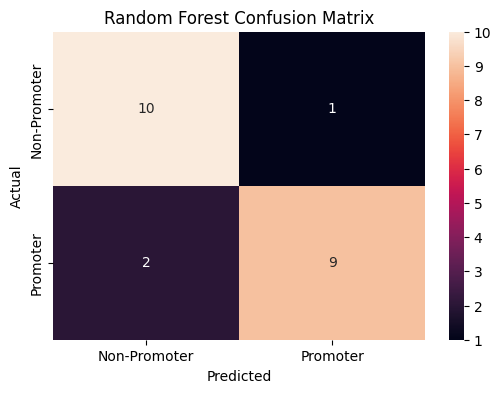

In [43]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["Non-Promoter", "Promoter"],
    yticklabels=["Non-Promoter", "Promoter"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

### STEP 19 — Compare the models

Let's create a DataFrame to compare the key performance metrics of both Logistic Regression and Random Forest models side-by-side.

In [44]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.772727      0.875  0.636364  0.736842
1        Random Forest  0.863636      0.900  0.818182  0.857143


### STEP 20 — Feature importance

Random Forest models can provide insights into which features (K-mers) were most important for making predictions. Let's extract and visualize the top 10 most important K-mers.

Top 10 Important K-mers:
   Kmer  Importance
0   AAA    0.115389
34  GAG    0.061205
12  ATA    0.056021
60  TTA    0.042678
33  GAC    0.033448
52  TCA    0.031713
21  CCC    0.029530
51  TAT    0.028611
63  TTT    0.028531
6   ACG    0.027654


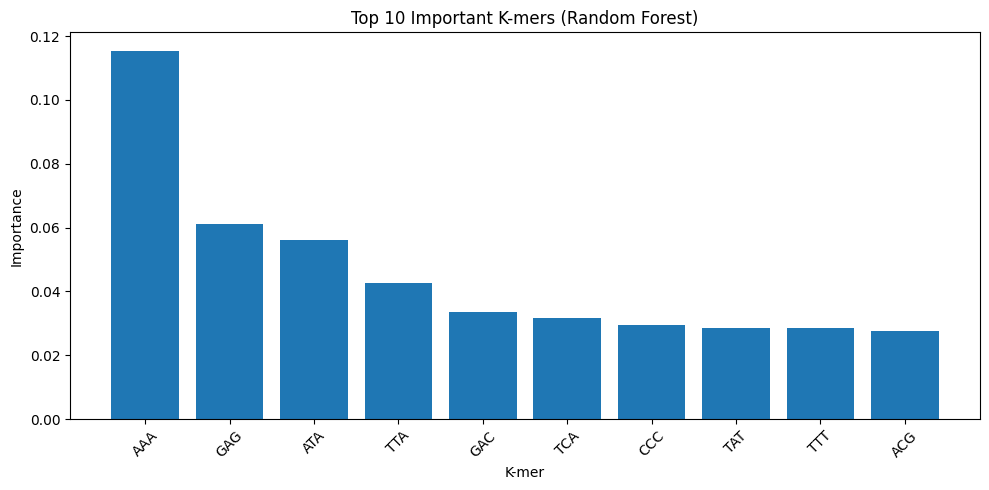

In [45]:
importance = pd.DataFrame({
    "Kmer": feature_names,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("Top 10 Important K-mers:")
print(importance.head(10))

top10 = importance.head(10)

plt.figure(figsize=(10, 5))

plt.bar(
    top10["Kmer"],
    top10["Importance"]
)

plt.xlabel("K-mer")
plt.ylabel("Importance")
plt.title("Top 10 Important K-mers (Random Forest)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### STEP 21 — Test your model with a new DNA sequence

This step demonstrates how to use the trained Random Forest model to predict the class of a new, unseen DNA sequence. We'll define a new sequence, convert it into K-mer features, and then make a prediction.

In [46]:
new_sequence = "TACTAGCAATACGCTTGCGTTCGGTGGTTAAGTATGTATAATGCGCGGGCTTGTCGT"

print("New sequence length:", len(new_sequence))

new_counts = kmer_frequency(new_sequence, k=3)

# The vectorizer expects a list of dictionaries
new_X = vectorizer.transform([new_counts]).toarray()

prediction = rf_model.predict(new_X)[0]

print(f"Predicted class (numeric): {prediction}")

if prediction == 1:
    print("Prediction: Promoter")
else:
    print("Prediction: Non-Promoter")

New sequence length: 57
Predicted class (numeric): 1
Prediction: Promoter


### STEP 22 — Save your trained model

It's good practice to save trained models and vectorizers so they can be reused without retraining. We'll use `joblib` for this.

In [47]:
import joblib
import os

# Create models directory if it doesn't exist
models_dir = "DNA-Kmer-Classifier/models"
if not os.path.exists(models_dir):
    os.makedirs(models_dir)

joblib.dump(rf_model, os.path.join(models_dir, "random_forest_model.pkl"))
joblib.dump(vectorizer, os.path.join(models_dir, "kmer_vectorizer.pkl"))

print("Model and vectorizer saved successfully.")

print("\nContents of models directory:")
!ls {models_dir}

Model and vectorizer saved successfully.

Contents of models directory:
kmer_vectorizer.pkl  random_forest_model.pkl


### STEP 23 — Save your results

We'll save the model comparison results and the K-mer importance dataframes to CSV files in the `results` directory.

In [48]:
# Create results directory if it doesn't exist
results_dir = "DNA-Kmer-Classifier/results"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

results.to_csv(
    os.path.join(results_dir, "model_comparison.csv"),
    index=False
)

importance.to_csv(
    os.path.join(results_dir, "kmer_importance.csv"),
    index=False
)

print("Results saved successfully.")

print("\nContents of results directory:")
!ls {results_dir}

Results saved successfully.

Contents of results directory:
kmer_importance.csv  model_comparison.csv


### STEP 24 — Save the cleaned dataset

Just to ensure the cleaned dataset is saved in the specified location. This was already done, but we'll include it here for completeness if running the notebook from scratch.

In [50]:
clean_file_path = "DNA-Kmer-Classifier/data/promoter_sequences_clean.csv"

# Create data directory if it doesn't exist
data_dir = "DNA-Kmer-Classifier/data"
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

df[["Label", "ID", "Sequence", "Class"]].to_csv(
    clean_file_path,
    index=False
)

print("Cleaned dataset (with Class column) saved successfully.")
print("\nContents of data directory:")
!ls {data_dir}

Cleaned dataset (with Class column) saved successfully.

Contents of data directory:
promoters.data	promoter_sequences_clean.csv
